In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from tone_datagen.tonegen import RandomToneGen, gamma, uniform, normal, clip, quant
from audiolazy import Streamix, sHz, zeros, ones, line, Stream
from pedalboard import Pedalboard, Reverb

In [ ]:
from tone_datagen.util import see, hear

In [ ]:
rate = 44100

In [ ]:
tonegen = RandomToneGen(
    gamma(3) * 100 + 20,
    gamma(2) * -2 - 2,
    uniform(0, 0.3) + clip(gamma(0.9) * 0.2, high=4),
    uniform(0.05, 0.6),
    uniform(),
    uniform(0.05, 1)
)

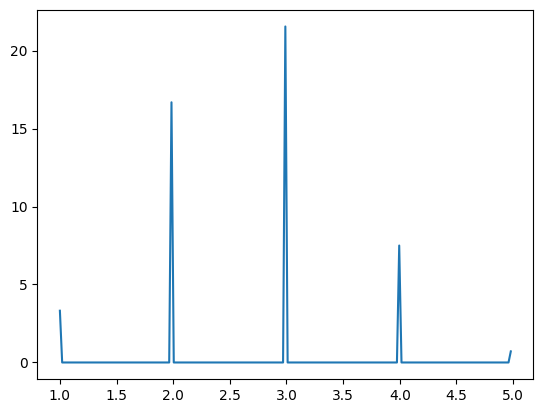

In [ ]:
quant(normal() * 0.8 + 2.7, range(1, 6)).pdf()

In [ ]:
smix = Streamix()
for _ in range(quant(normal() * 0.8 + 2.7, range(1, 6))()):
    smix.add(0, tonegen())

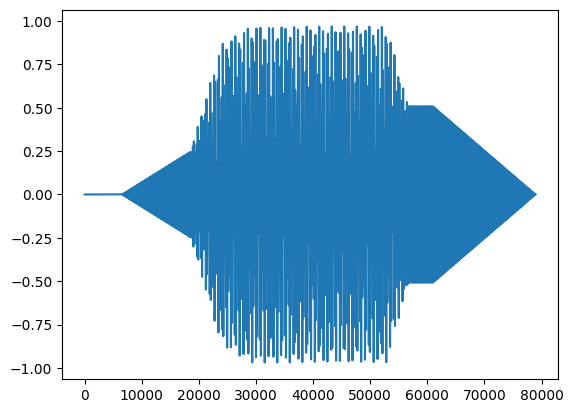

In [ ]:
see(smix)

In [ ]:
hear(smix)

In [ ]:
list(smix)

In [ ]:
reverb = Pedalboard([Reverb(wet_level=1, dry_level=0)])

In [ ]:
import numpy as np

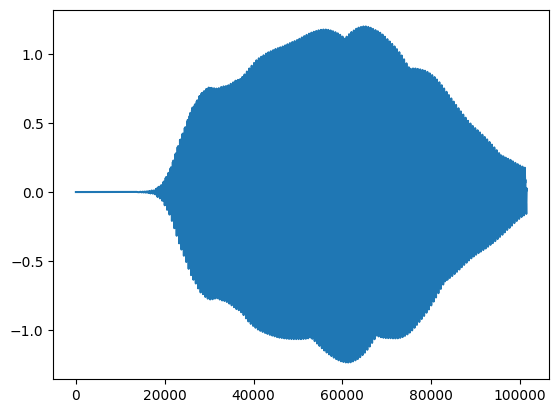

In [ ]:
see(reverb(np.array(list(smix.copy())), rate))

In [ ]:
hear(reverb(np.array(list(smix.copy())), rate))

In [ ]:
s, Hz = sHz(rate)

In [ ]:
smix.append(zeros(s))

<audiolazy.lazy_stream.Streamix>

In [ ]:
hear(reverb(np.array(list(smix.copy())), rate))

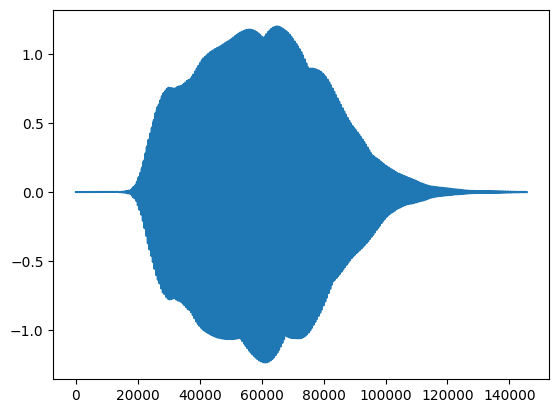

In [ ]:
see(reverb(np.array(list(smix.copy())), rate))

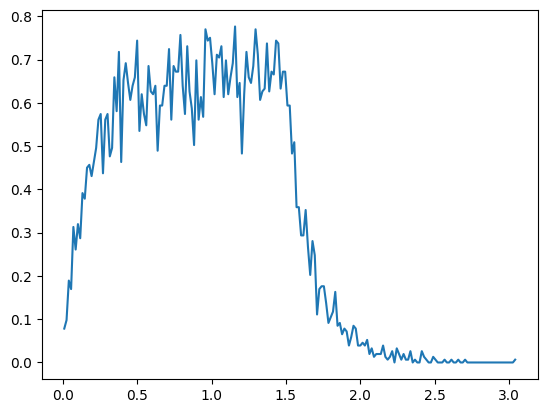

In [ ]:
(uniform(0, 1.5) + clip(gamma(0.9) * 0.2, high=4)).pdf()

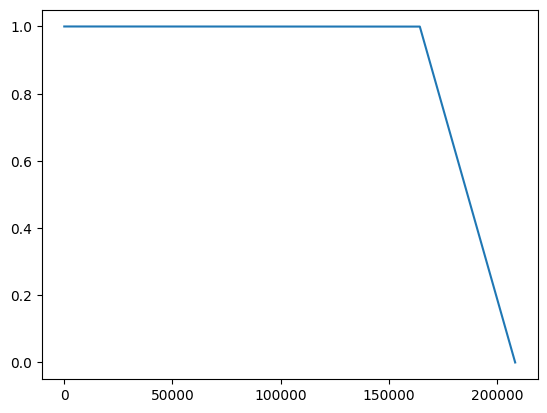

In [ ]:
s, Hz = sHz(rate)
tonegen = RandomToneGen(
    gamma(3) * 100 + 20,
    gamma(2) * -2 - 2,
    uniform(0, 1.5) + clip(gamma(0.9) * 0.2, high=4),
    uniform(0.05, 0.6),
    uniform(),
    uniform(0.05, 1)
)
reverb = Pedalboard([Reverb(wet_level=1, dry_level=0.2, room_size=0.75)])

smix = Streamix()
for _ in range(quant(normal() * 0.8 + 2.7, range(1, 6))()):
    smix.add(0, tonegen())

env = Stream(ones(len(list(smix.copy())) + s), line(s, 1, 0))
see(env.copy())

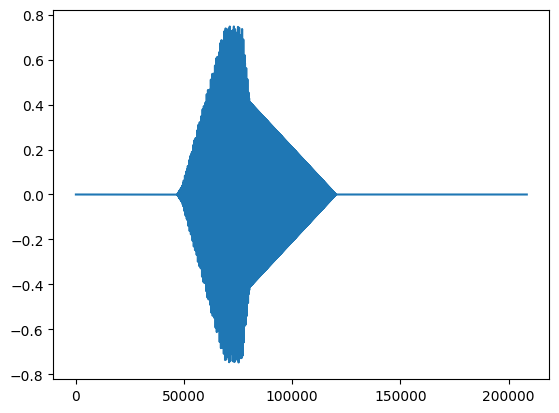

In [ ]:
smix.append(zeros(s * 2))
mix = np.array(list(smix * env.copy()))
see(mix)


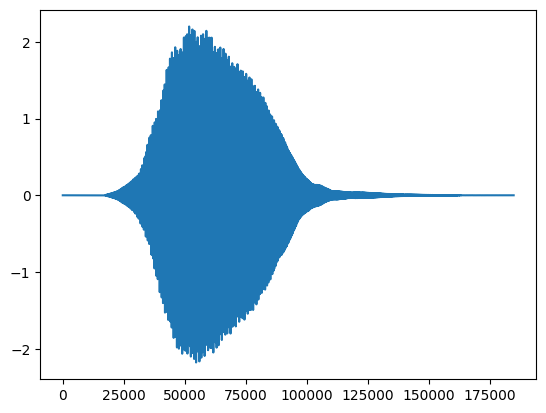

In [ ]:
max_abs = np.max(np.abs(mix))
if max_abs > 1:
    mix /= max_abs

see(np.array(list(env * reverb(mix, rate))))


In [ ]:
def normalised(stream):
    mix = np.array(list(stream))
    max_abs = np.max(np.abs(mix))
    if max_abs > 1:
        mix /= max_abs

    return mix

In [ ]:
def mixed_tones(rate=44100):
    s, Hz = sHz(rate)
    tonegen = RandomToneGen(
        gamma(3) * 100 + 20,
        gamma(2) * -2 - 2,
        uniform(0, 1.5) + clip(gamma(0.9) * 0.2, high=4),
        uniform(0.05, 0.6),
        uniform(),
        uniform(0.05, 1)
    )
    reverb = Pedalboard([Reverb(wet_level=1, dry_level=0.2, room_size=0.75)])
    
    smix = Streamix()
    for _ in range(quant(normal() * 0.8 + 2.7, range(1, 6))()):
        smix.add(0, tonegen())
    env = Stream(ones(len(list(smix.copy())) + s), line(s, 1, 0))
    # make stream as long as envelope
    smix.append(zeros(s * 2))

    mix = normalised(smix)
    return normalised(env * reverb(mix, rate))

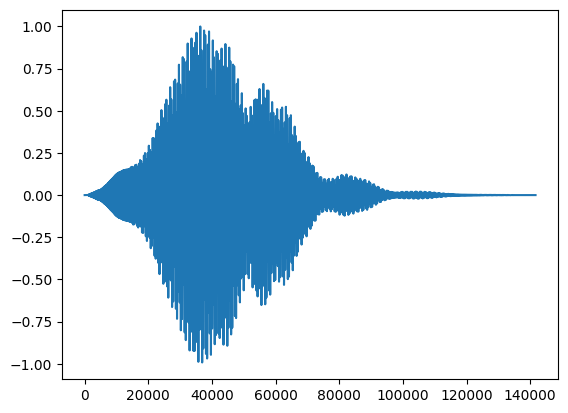

3.2127437641723358

In [ ]:
gend = mixed_tones()
see(gend)
hear(gend)
len(gend) / rate